# Predicting Neighborhood-Level Influenza Outbreaks in Boston Using Graph Neural Networks

This notebook implements a **Spatio-Temporal Graph Neural Network (ST-GNN)** using **PyTorch** and **PyTorch Geometric** to predict influenza case rates at the neighborhood level in Boston.

**Pipeline:**
1. Load & preprocess real BPHC, MDPH, and City of Boston data from `../Data/`
2. Construct a geographic adjacency graph over 14 Boston neighborhoods + 1 background anchor node
3. Train a GCN-based model with global covariate fusion
4. Evaluate and visualize predictions

**Data folder structure expected:**
```
Data/
├── BPHC/
│   ├── BPHC Dashboard Influenza Demographics.csv
│   ├── BPHC Dashboard Influenza ED Visits-type 1.csv
│   ├── BPHC Dashboard Influenza ED Visits-type 2.csv
│   ├── BPHC Dashboard Influenza Neighborhood.csv
│   └── BPHC Dashboard Influenza Wastewater.csv
├── Mass/
│   ├── Mass Dashboard Vaccination Data 2023-2024.xlsx
│   ├── Mass Dashboard Vaccination Data 2024-2025.xlsx
│   └── Mass Dashboard Vaccination Data 2025-2026.xlsx
└── CityOfBoston/
    ├── Age_in_Boston.csv
    ├── Children_by_Age_in_Boston.csv
    ├── Commute_Mode_in_Boston.csv
    ├── Housing_Tenure_in_Boston.csv
    ├── Housing_Units_in_Boston.csv
    ├── Population_in_Boston.csv
    ├── Poverty_Status_in_Boston.csv
    ├── Race_and_Ethnicity_in_Boston.csv
    └── Vehicles_Available_in_Boston.csv
```


## 0. Setup & Imports

In [1]:
# --- Uncomment and run once to install dependencies ---
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#!pip install torch-geometric
#!pip install openpyxl

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

np.random.seed(42)
torch.manual_seed(42)
sns.set_theme(style="whitegrid", font_scale=1.1)

# --- Paths ---
DATA_DIR = os.path.join('..', 'Data')
BPHC_DIR = os.path.join(DATA_DIR, 'BPHC Flu Data')
MASS_DIR = os.path.join(DATA_DIR, 'Mass Flu Vaccination Data')
CITY_DIR = os.path.join(DATA_DIR, 'Neighborhood Data')

for d in [BPHC_DIR, MASS_DIR, CITY_DIR]:
    assert os.path.isdir(d), f"Missing directory: {d}"
print("All data directories found.")


Using device: cuda
GPU: NVIDIA GeForce RTX 4060
All data directories found.


## 1. Neighborhood Definitions & Mappings

The 14 model neighborhoods and how each data source maps to them.


In [2]:
# --- 14 canonical neighborhoods used as graph nodes ---
NEIGHBORHOODS = [
    'Allston/Brighton',
    'Back Bay/Beacon Hill/Downtown/North End/West End',
    'Charlestown',
    'Dorchester',
    'East Boston',
    'Fenway',
    'Hyde Park',
    'Jamaica Plain',
    'Mattapan',
    'Roslindale',
    'Roxbury',
    'South Boston',
    'South End',
    'West Roxbury',
]
SHORT_NAMES = [
    'Allston', 'BackBay+', 'Charles.', 'Dorchest.', 'E.Boston',
    'Fenway', 'HydePark', 'JP', 'Mattapan', 'Roslind.',
    'Roxbury', 'S.Boston', 'S.End', 'W.Roxbury',
]
N_NEIGH = len(NEIGHBORHOODS)
BG_NODE = 'Background'
ALL_NODES = SHORT_NAMES + [BG_NODE]
N_NODES = N_NEIGH + 1
BG_IDX = N_NEIGH

# --- Mapping: BPHC Neighborhood CSV values -> canonical index ---
# BPHC has two Dorchester rows that we average
BPHC_TO_IDX = {
    'Allston/Brighton': 0,
    'Back Bay, Beacon Hill, Downtown, North End, West End': 1,
    'Charlestown': 2,
    'Dorchester (02121, 02125)': 3,   # averaged with next
    'Dorchester (02122, 02124)': 3,   # averaged with above
    'East Boston': 4,
    'Fenway': 5,
    'Hyde Park': 6,
    'Jamaica Plain': 7,
    'Mattapan': 8,
    'Roslindale': 9,
    'Roxbury': 10,
    'South Boston': 11,
    'South End': 12,
    'West Roxbury': 13,
}

# --- Mapping: Wastewater neighborhood -> canonical index ---
# Some wastewater zones cover multiple model neighborhoods
WASTEWATER_TO_IDX = {
    'Allston/Brighton': [0],
    'Back Bay': [1, 5, 11, 12],  # Back Bay zone covers BackBay+, Fenway, S.Boston, S.End
    'Charlestown': [2],
    'Dorchester': [3],
    'East Boston': [4],
    'Hyde Park': [6],
    'Jamaica Plain': [7],
    'Mattapan': [8],
    'Roslindale/West Roxbury': [9, 13],
    'Roxbury': [10],
}

# --- Mapping: City of Boston GEOIDs -> canonical index ---
# Multiple sub-neighborhoods aggregate into one model node
GEOID_TO_IDX = {
    'Allston': 0, 'Brighton': 0,
    'Back Bay': 1, 'Beacon Hill': 1, 'Downtown': 1, 'North End': 1, 'West End': 1,
    'Charlestown': 2,
    'Dorchester': 3,
    'East Boston': 4,
    'Fenway': 5, 'Longwood': 5,
    'Hyde Park': 6,
    'Jamaica Plain': 7,
    'Mattapan': 8,
    'Roslindale': 9,
    'Mission Hill': 10, 'Roxbury': 10,
    'South Boston': 11, 'South Boston Waterfront': 11,
    'Chinatown': 12, 'South End': 12,
    'West Roxbury': 13,
}

# Approximate geographic centers (lon, lat) for plotting
COORDS = {
    'Allston':    (-71.1310, 42.3535),
    'BackBay+':   (-71.0680, 42.3550),
    'Charles.':   (-71.0600, 42.3780),
    'Dorchest.':  (-71.0560, 42.3000),
    'E.Boston':   (-71.0200, 42.3750),
    'Fenway':     (-71.1000, 42.3430),
    'HydePark':   (-71.1250, 42.2560),
    'JP':         (-71.1150, 42.3100),
    'Mattapan':   (-71.0940, 42.2720),
    'Roslind.':   (-71.1350, 42.2830),
    'Roxbury':    (-71.0870, 42.3270),
    'S.Boston':   (-71.0380, 42.3350),
    'S.End':      (-71.0700, 42.3400),
    'W.Roxbury':  (-71.1580, 42.2790),
    'Background': (-71.0000, 42.3500),
}

print(f"Defined {N_NEIGH} neighborhoods + 1 background node = {N_NODES} total nodes.")


Defined 14 neighborhoods + 1 background node = 15 total nodes.


## 2. Data Loading

### 2a. BPHC Neighborhood Weekly Flu Rates


In [3]:
# -------------------------------------------------------
# 2a. BPHC Neighborhood flu rates (weekly)
# -------------------------------------------------------
nbr_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza Neighborhood.csv'))

# Keep only weekly rows
nbr_weekly = nbr_df[nbr_df['date_type'] == 'Weekly'].copy()
nbr_weekly['date_start'] = pd.to_datetime(nbr_weekly['date_value_start'])
nbr_weekly['value'] = pd.to_numeric(nbr_weekly['value'], errors='coerce')

# --- Diagnostic: print actual neighborhood names in the CSV ---
actual_names = sorted(nbr_weekly['demographic_value'].unique())

# --- Build mapping dynamically by matching keywords ---
def build_bphc_mapping(actual_names):
    """Match actual CSV neighborhood names to canonical indices."""
    mapping = {}
    # Longer/more specific keywords first to avoid partial matches
    # (e.g. "west roxbury" must match before "roxbury")
    keyword_to_idx = [
        ('west roxbury', 13),
        ('south boston', 11),
        ('south end', 12),
        ('east boston', 4),
        ('hyde park', 6),
        ('jamaica plain', 7),
        ('back bay', 1), ('beacon hill', 1), ('downtown', 1), ('north end', 1), ('west end', 1),
        ('bb/bh/dt/ne/we', 1),  # abbreviated form
        ('allston', 0), ('brighton', 0),
        ('charlestown', 2),
        ('dorchester', 3), ('dor ', 3), ('dor(', 3),  # abbreviated forms
        ('fenway', 5),
        ('mattapan', 8),
        ('roslindale', 9),
        ('roxbury', 10),
    ]
    for name in actual_names:
        name_lower = name.lower().strip()
        for keyword, idx in keyword_to_idx:
            if keyword in name_lower:
                mapping[name] = idx
                break
    return mapping

BPHC_TO_IDX = build_bphc_mapping(actual_names)

print("\nResolved mapping:")
for name, idx in sorted(BPHC_TO_IDX.items(), key=lambda x: x[1]):
    print(f"  '{name}' → {idx} ({SHORT_NAMES[idx]})")

# Check for unmapped names
unmapped = [n for n in actual_names if n not in BPHC_TO_IDX]
if unmapped:
    print(f"\n⚠️  UNMAPPED names: {unmapped}")

# Map to canonical neighborhood index
nbr_weekly['node_idx'] = nbr_weekly['demographic_value'].map(BPHC_TO_IDX)
nbr_weekly = nbr_weekly.dropna(subset=['node_idx', 'value'])
nbr_weekly['node_idx'] = nbr_weekly['node_idx'].astype(int)

# For Dorchester: multiple rows may map to same index → average them per week
flu_rates = (nbr_weekly
             .groupby(['date_start', 'node_idx'])['value']
             .mean()
             .reset_index())

# Pivot: rows = weeks, columns = neighborhoods
flu_pivot = flu_rates.pivot(index='date_start', columns='node_idx', values='value')
flu_pivot = flu_pivot.sort_index().fillna(0)

# Ensure all 14 neighborhoods present
for i in range(N_NEIGH):
    if i not in flu_pivot.columns:
        flu_pivot[i] = 0.0
flu_pivot = flu_pivot[sorted(flu_pivot.columns)]

print(f"\nWeekly flu rates: {flu_pivot.shape[0]} weeks × {flu_pivot.shape[1]} neighborhoods")
print(f"Date range: {flu_pivot.index.min().date()} to {flu_pivot.index.max().date()}")
print(f"\nSample (first 10 weeks):")
display_df = flu_pivot.head(10).copy()
display_df.columns = [SHORT_NAMES[c] for c in display_df.columns]
print(display_df.to_string())


Resolved mapping:
  'Allston/Brighton' → 0 (Allston)
  'BB/BH/DT/NE/WE' → 1 (BackBay+)
  'Charlestown' → 2 (Charles.)
  'Dor (02121, 02125)' → 3 (Dorchest.)
  'Dor (02122, 02124)' → 3 (Dorchest.)
  'East Boston' → 4 (E.Boston)
  'Fenway' → 5 (Fenway)
  'Hyde Park' → 6 (HydePark)
  'Jamaica Plain' → 7 (JP)
  'Mattapan' → 8 (Mattapan)
  'Roslindale' → 9 (Roslind.)
  'Roxbury' → 10 (Roxbury)
  'South Boston' → 11 (S.Boston)
  'South End' → 12 (S.End)
  'West Roxbury' → 13 (W.Roxbury)

Weekly flu rates: 422 weeks × 14 neighborhoods
Date range: 2017-12-31 to 2026-01-25

Sample (first 10 weeks):
            Allston  BackBay+  Charles.  Dorchest.  E.Boston  Fenway  HydePark     JP  Mattapan  Roslind.  Roxbury  S.Boston  S.End  W.Roxbury
date_start                                                                                                                                    
2017-12-31    12.05      6.80      6.15     47.425     10.25    5.80     13.25  17.55     17.25     24.15    42.65  

### 2b. BPHC ED Visit Counts & Percentages (city-wide weekly)

In [4]:
# -------------------------------------------------------
# 2b. ED Visits — Type 1 (raw counts) and Type 2 (percentages)
# -------------------------------------------------------
ed1_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza ED Visits-type 1.csv'))
ed2_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza ED Visits-type 2.csv'))

ed1_df['date_start'] = pd.to_datetime(ed1_df['date_value_start'])
ed1_df['ili_count'] = pd.to_numeric(ed1_df['value'], errors='coerce')
ed1_weekly = ed1_df.groupby('date_start')['ili_count'].sum().reset_index()

ed2_df['date_start'] = pd.to_datetime(ed2_df['date_value_start'])
ed2_df['ili_pct'] = pd.to_numeric(ed2_df['value'], errors='coerce')
ed2_weekly = ed2_df.groupby('date_start')['ili_pct'].mean().reset_index()

# Merge
ed_merged = pd.merge(ed1_weekly, ed2_weekly, on='date_start', how='outer').sort_values('date_start')
ed_merged = ed_merged.set_index('date_start')

print(f"ED visits: {len(ed_merged)} weeks")
print(f"Date range: {ed_merged.index.min().date()} to {ed_merged.index.max().date()}")
print(ed_merged.head())


ED visits: 422 weeks
Date range: 2017-12-31 to 2026-01-25
               ili_count   ili_pct
date_start                        
2017-12-31  10943.993122  3.993122
2018-01-07  14244.146754  4.146754
2018-01-14  14378.156158  5.156158
2018-01-21  15048.643757  6.643757
2018-01-28  16136.870196  8.870196


### 2c. BPHC Wastewater Surveillance (resampled to weekly)

In [5]:
# -------------------------------------------------------
# 2c. Wastewater — irregular daily → resample to weekly per neighborhood
# -------------------------------------------------------
ww_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza Wastewater.csv'))
ww_df['date'] = pd.to_datetime(ww_df['date_value_start'])
ww_df['value'] = pd.to_numeric(ww_df['value'], errors='coerce')

# Assign wastewater zone to all mapped canonical neighborhoods
ww_rows = []
for _, row in ww_df.iterrows():
    zone = row['demographic_value']
    if zone in WASTEWATER_TO_IDX:
        for idx in WASTEWATER_TO_IDX[zone]:
            ww_rows.append({
                'date': row['date'],
                'node_idx': idx,
                'ww_value': row['value']
            })

ww_expanded = pd.DataFrame(ww_rows)
ww_expanded['week_start'] = ww_expanded['date'] - pd.to_timedelta(ww_expanded['date'].dt.dayofweek, unit='D')

# Weekly mean per neighborhood
ww_weekly = (ww_expanded
             .groupby(['week_start', 'node_idx'])['ww_value']
             .mean()
             .reset_index())

ww_pivot = ww_weekly.pivot(index='week_start', columns='node_idx', values='ww_value')
ww_pivot = ww_pivot.sort_index().fillna(0)
for i in range(N_NEIGH):
    if i not in ww_pivot.columns:
        ww_pivot[i] = 0.0
ww_pivot = ww_pivot[sorted(ww_pivot.columns)]

print(f"Wastewater (weekly): {ww_pivot.shape[0]} weeks × {ww_pivot.shape[1]} neighborhoods")
print(f"Date range: {ww_pivot.index.min().date()} to {ww_pivot.index.max().date()}")


Wastewater (weekly): 79 weeks × 14 neighborhoods
Date range: 2024-07-29 to 2026-01-26


### 2d. BPHC Demographics (monthly case counts by gender/age/race)

In [6]:
# -------------------------------------------------------
# 2d. Demographics case counts — monthly, city-wide by category
# -------------------------------------------------------
demo_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza Demographics.csv'))
demo_df['date_start'] = pd.to_datetime(demo_df['date_value_start'])
demo_df['value'] = pd.to_numeric(demo_df['value'], errors='coerce')

# Pivot to get total cases per month (sum across all categories for a rough city total)
demo_monthly = (demo_df
                .groupby(['date_start', 'demographic_category'])['value']
                .sum()
                .reset_index())

# We'll use the gender total (Female+Male) as a proxy for monthly city-wide confirmed cases
gender_monthly = (demo_df[demo_df['demographic_category'] == 'Gender']
                  .groupby('date_start')['value']
                  .sum()
                  .reset_index()
                  .rename(columns={'value': 'monthly_cases'}))

# Resample to weekly by forward-filling the monthly value
gender_monthly = gender_monthly.set_index('date_start').resample('W-SUN').ffill()

print(f"Demographic monthly cases: {len(gender_monthly)} weekly entries (forward-filled)")
print(gender_monthly.head())


Demographic monthly cases: 418 weekly entries (forward-filled)
            monthly_cases
date_start               
2018-01-07            491
2018-01-14            491
2018-01-21            491
2018-01-28            491
2018-02-04            701


### 2e. MDPH Vaccination Data

In [7]:
def load_city_csv(filename, value_cols, agg='sum'):
    """Load a City of Boston CSV file and aggregate GEOIDs to canonical neighborhoods."""
    filepath = os.path.join(CITY_DIR, filename)

    # Find the row where the actual CSV header starts (contains "GEOID")
    skiprows = 0
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if '"GEOID"' in line or 'GEOID' in line:
                skiprows = i
                break

    df = pd.read_csv(filepath, skiprows=skiprows)
    df['node_idx'] = df['GEOID'].map(GEOID_TO_IDX)
    df = df.dropna(subset=['node_idx'])
    df['node_idx'] = df['node_idx'].astype(int)

    # Use most recent year
    latest_year = df['YEAR'].max()
    df_latest = df[df['YEAR'] == latest_year].copy()

    if agg == 'sum':
        result = df_latest.groupby('node_idx')[value_cols].sum()
    else:
        result = df_latest.groupby('node_idx')[value_cols].mean()

    return result, latest_year

# Age
age_df, age_year = load_city_csv('Age_in_Boston.csv',
                                  ['0-9 years', '10-19 years', '20-34 years',
                                   '35-54 years', '55-64 years', '65 years and over'])

In [8]:
# -------------------------------------------------------
# 2e. Mass vaccination — from xlsx files, filter Town=Boston
#     Extract Total (global covariate) + Age-group rates, then compute
#     per-neighborhood estimated vaccination using age-weighted approach.
#     Season is extracted from filename (no Season column in data).
# -------------------------------------------------------
vacc_records = []
vacc_age_records = []
vacc_files = sorted(glob.glob(os.path.join(MASS_DIR, 'Mass Dashboard Vaccination Data *.xlsx')))

for fpath in vacc_files:
    fname = os.path.basename(fpath)
    season = fname.replace('Mass Dashboard Vaccination Data ', '').replace('.xlsx', '').strip()

    df = pd.read_excel(fpath, sheet_name='Influenza Town Data')
    boston = df[df['Town'] == 'Boston'].copy()

    # --- Total row (global covariate) ---
    total_row = boston[boston['Subgroup'] == 'Total vaccinated individuals']
    if len(total_row) > 0:
        row = total_row.iloc[0]
        pct_str = str(row['Percent of people vaccinated']).replace('%', '').strip()
        try:
            if '-' in pct_str:
                # Handle range format like "40%-60%" → midpoint 0.50
                parts = pct_str.split('-')
                pct = (float(parts[0].strip()) + float(parts[1].strip())) / 2.0 / 100.0
            else:
                pct = float(pct_str) / 100.0
        except:
            pct = np.nan
        vacc_records.append({
            'season': season,
            'start_date': pd.to_datetime(row['Start Date']),
            'end_date': pd.to_datetime(row['End Date']),
            'vaccination_rate': pct,
            'population': row['Population estimate'],
        })

    # --- Age-group rows ---
    age_rows = boston[boston['Group'] == 'Age'].copy()
    for _, arow in age_rows.iterrows():
        pct_str = str(arow['Percent of people vaccinated']).replace('%', '').strip()
        try:
            if '-' in pct_str:
                # Handle range format like "40%-60%" → midpoint 0.50
                parts = pct_str.split('-')
                pct = (float(parts[0].strip()) + float(parts[1].strip())) / 2.0 / 100.0
            else:
                pct = float(pct_str) / 100.0
        except:
            pct = np.nan
        vacc_age_records.append({
            'season': season,
            'start_date': pd.to_datetime(arow['Start Date']),
            'end_date': pd.to_datetime(arow['End Date']),
            'subgroup': arow['Subgroup'],
            'vaccination_rate': pct,
        })

vacc_df = pd.DataFrame(vacc_records)
vacc_age_df = pd.DataFrame(vacc_age_records)

print("Global vaccination rates:")
print(vacc_df[['season', 'vaccination_rate']].to_string(index=False))
print(f"\nAge-group vaccination rates ({len(vacc_age_df)} records):")
print(vacc_age_df.pivot(index='subgroup', columns='season', values='vaccination_rate').round(3).to_string())

# -------------------------------------------------------
# Map Mass vaccination age bins → City of Boston census age bins
# Census bins: 0-9, 10-19, 20-34, 35-54, 55-64, 65+
# Vacc bins:   <5, 5-19, 20-34, 35-49, 50-64, 65-79, 80+
#
# Approximate alignment (noted where imperfect):
#   Census 0-9   ← avg(Under 5, 5-19)    [overlap: 5-9 counted in both]
#   Census 10-19 ← 5-19                   [overlap: 10-19 exact, 5-9 extra]
#   Census 20-34 ← 20-34                  [exact]
#   Census 35-54 ← avg(35-49, 50-64)     [50-54 leaks from next bin]
#   Census 55-64 ← 50-64                  [50-54 overlap with above]
#   Census 65+   ← avg(65-79, 80+)       [exact]
# -------------------------------------------------------
VACC_TO_CENSUS_MAP = {
    '0-9 years':          ['Under 5 Years', '5-19 years'],
    '10-19 years':        ['5-19 years'],
    '20-34 years':        ['20-34 years'],
    '35-54 years':        ['35-49 years', '50-64 years'],
    '55-64 years':        ['50-64 years'],
    '65 years and over':  ['65-79 years', '80+ years'],
}

def compute_neighborhood_vaccination(season_label):
    """
    Compute per-neighborhood estimated vaccination rate for a given season
    by weighting age-specific city-wide rates by each neighborhood's age distribution.
    Returns array of shape (N_NEIGH,).
    """
    season_age = vacc_age_df[vacc_age_df['season'] == season_label]
    subgroup_rates = dict(zip(season_age['subgroup'], season_age['vaccination_rate']))

    # Map each census age bin to an average vaccination rate
    census_bin_rates = {}
    for census_bin, vacc_bins in VACC_TO_CENSUS_MAP.items():
        rates = [subgroup_rates.get(vb, np.nan) for vb in vacc_bins]
        rates = [r for r in rates if not np.isnan(r)]
        census_bin_rates[census_bin] = np.mean(rates) if rates else 0.0

    # age_df has raw counts per census bin per neighborhood (indexed by node_idx)
    census_cols = list(VACC_TO_CENSUS_MAP.keys())
    age_counts = age_df[census_cols]  # (N_NEIGH, 6)
    age_totals = age_counts.sum(axis=1)

    # Weighted vaccination rate per neighborhood
    nbr_vacc = np.zeros(N_NEIGH)
    for i in range(N_NEIGH):
        if i in age_counts.index and age_totals.get(i, 0) > 0:
            weighted = sum(
                (age_counts.loc[i, col] / age_totals[i]) * census_bin_rates[col]
                for col in census_cols
            )
            nbr_vacc[i] = weighted
        else:
            # Fallback to city-wide total
            total = vacc_df[vacc_df['season'] == season_label]['vaccination_rate'].values
            nbr_vacc[i] = total[0] if len(total) > 0 else 0.3

    return nbr_vacc

# Compute for each season
vacc_by_season = {}
for _, row in vacc_df.iterrows():
    nbr_rates = compute_neighborhood_vaccination(row['season'])
    vacc_by_season[row['season']] = {
        'start': row['start_date'],
        'end': row['end_date'],
        'global_rate': row['vaccination_rate'],
        'neighborhood_rates': nbr_rates,
    }

print("\nPer-neighborhood estimated vaccination rates:")
for season, info in vacc_by_season.items():
    print(f"\n  {season} (global: {info['global_rate']:.1%}):")
    for i, n in enumerate(SHORT_NAMES):
        print(f"    {n:12s}: {info['neighborhood_rates'][i]:.1%}")

Global vaccination rates:
   season  vaccination_rate
2023-2024             0.413
2024-2025             0.400
2025-2026             0.350

Age-group vaccination rates (21 records):
season         2023-2024  2024-2025  2025-2026
subgroup                                      
20-34 years          0.3       0.30       0.24
35-49 years          0.5       0.40       0.37
5-19 years           0.3       0.36       0.32
50-64 years          0.5       0.40       0.40
65-79 years          0.7       0.67       0.55
80+ years            0.7       0.66       0.55
Under 5 Years        0.5       0.58       0.50

Per-neighborhood estimated vaccination rates:

  2023-2024 (global: 41.3%):
    Allston     : 37.9%
    BackBay+    : 42.7%
    Charles.    : 44.7%
    Dorchest.   : 43.7%
    E.Boston    : 42.2%
    Fenway      : 34.4%
    HydePark    : 47.1%
    JP          : 43.9%
    Mattapan    : 46.1%
    Roslind.    : 46.3%
    Roxbury     : 41.7%
    S.Boston    : 41.1%
    S.End       : 43.8%
    W.R

### 2f. City of Boston Static Demographics

In [9]:
# -------------------------------------------------------
# 2f. City of Boston CSVs — aggregate sub-neighborhoods to model nodes
#     Use most recent year available for each dataset
#     NOTE: City of Boston CSVs have metadata header rows before the actual
#     CSV data. We detect the real header by finding the row starting with "GEOID".
# -------------------------------------------------------

# Population
pop_df, pop_year = load_city_csv('Population_in_Boston.csv',
                                  ['Male', 'Female', 'Population per square mile'])
pop_df['total_pop'] = pop_df['Male'] + pop_df['Female']
print(f"Population (year {pop_year}): {len(pop_df)} neighborhoods")

# Age
age_total = age_df.sum(axis=1)
age_df['pct_children'] = (age_df['0-9 years'] + age_df['10-19 years']) / age_total
age_df['pct_elderly'] = age_df['65 years and over'] / age_total
age_df['pct_20_34'] = age_df['20-34 years'] / age_total
print(f"Age (year {age_year}): {len(age_df)} neighborhoods")

# Commute mode
commute_df, comm_year = load_city_csv('Commute_Mode_in_Boston.csv',
                                       ['Public transit', 'Walked',
                                        'Car, truck, or van - drove alone',
                                        'Car, truck, or van - carpooled',
                                        'Worked from home'])
commute_total = commute_df.sum(axis=1)
commute_df['transit_share'] = commute_df['Public transit'] / commute_total
commute_df['walk_share'] = commute_df['Walked'] / commute_total
print(f"Commute mode (year {comm_year}): {len(commute_df)} neighborhoods")

# Poverty
pov_df, pov_year = load_city_csv('Poverty_Status_in_Boston.csv',
                                   ['Below poverty line', 'Above poverty line'])
pov_df['poverty_rate'] = pov_df['Below poverty line'] / (pov_df['Below poverty line'] + pov_df['Above poverty line'])
print(f"Poverty (year {pov_year}): {len(pov_df)} neighborhoods")

# Housing tenure
tenure_df, ten_year = load_city_csv('Housing_Tenure_in_Boston.csv',
                                      ['Owner-occupied', 'Renter-occupied'])
tenure_df['owner_rate'] = tenure_df['Owner-occupied'] / (tenure_df['Owner-occupied'] + tenure_df['Renter-occupied'])
print(f"Housing tenure (year {ten_year}): {len(tenure_df)} neighborhoods")

# Housing units
units_df, units_year = load_city_csv('Housing_Units_in_Boston.csv',
                                       ['Occupied', 'Vacant', 'Total housing units'])
units_df['vacancy_rate'] = units_df['Vacant'] / units_df['Total housing units']
print(f"Housing units (year {units_year}): {len(units_df)} neighborhoods")

# Vehicles
veh_df, veh_year = load_city_csv('Vehicles_Available_in_Boston.csv',
                                   ['0 vehicles', '1+ vehicles'])
veh_df['no_vehicle_rate'] = veh_df['0 vehicles'] / (veh_df['0 vehicles'] + veh_df['1+ vehicles'])
print(f"Vehicles (year {veh_year}): {len(veh_df)} neighborhoods")

# Race/ethnicity
race_df, race_year = load_city_csv('Race_and_Ethnicity_in_Boston.csv',
                                     ['White', 'Black/African American',
                                      'Hispanic/Latino', 'Asian/Pacific Islander'])
race_total = race_df.sum(axis=1)
race_df['nonwhite_share'] = 1 - (race_df['White'] / race_total)
print(f"Race/ethnicity (year {race_year}): {len(race_df)} neighborhoods")

# --- Assemble static demographic vector per neighborhood ---
# Features: pop_density, poverty_rate, transit_share, pct_children,
#           pct_elderly, owner_rate, no_vehicle_rate, nonwhite_share
static_features = pd.DataFrame(index=range(N_NEIGH))
static_features['pop_density'] = pop_df['Population per square mile']
static_features['poverty_rate'] = pov_df['poverty_rate']
static_features['transit_share'] = commute_df['transit_share']
static_features['pct_children'] = age_df['pct_children']
static_features['pct_elderly'] = age_df['pct_elderly']
static_features['owner_rate'] = tenure_df['owner_rate']
static_features['no_vehicle_rate'] = veh_df['no_vehicle_rate']
#static_features['nonwhite_share'] = race_df['nonwhite_share']

# Fill any missing neighborhoods with median
static_features = static_features.fillna(static_features.median())

# Normalize each feature to [0, 1]
for col in static_features.columns:
    mn, mx = static_features[col].min(), static_features[col].max()
    if mx > mn:
        static_features[col] = (static_features[col] - mn) / (mx - mn)
    else:
        static_features[col] = 0.5

static_np = static_features.values.astype(np.float32)  # (14, 8)
print(f"\nStatic feature matrix that is normalized: {static_np.shape}")
print(static_features.round(4).to_string())


Population (year 2025): 14 neighborhoods
Age (year 2025): 14 neighborhoods
Commute mode (year 2025): 14 neighborhoods
Poverty (year 2025): 14 neighborhoods
Housing tenure (year 2025): 14 neighborhoods
Housing units (year 2025): 14 neighborhoods
Vehicles (year 2025): 14 neighborhoods
Race/ethnicity (year 2025): 14 neighborhoods

Static feature matrix that is normalized: (14, 7)
    pop_density  poverty_rate  transit_share  pct_children  pct_elderly  owner_rate  no_vehicle_rate
0        0.2097        0.5360         0.5397        0.0322       0.2278      0.1403           0.5453
1        1.0000        0.2455         0.1046        0.0443       0.6519      0.4068           0.8617
2        0.0452        0.0050         0.2520        0.5464       0.5118      0.7274           0.1702
3        0.0603        0.4621         0.5013        0.9209       0.4832      0.4967           0.3223
4        0.0198        0.3039         1.0000        0.7350       0.2497      0.3007           0.4412
5        0.349

## 3. Geographic Adjacency Graph

Edges based **only on geographic adjacency** (shared borders). The background anchor node connects to boundary neighborhoods (East Boston, South Boston, Charlestown).


In [10]:
# --- Geographic adjacency edges (hand-coded from Boston map) ---
# Using SHORT_NAMES indices
GEO_EDGES = [
    # Allston(0) neighbors
    ('Allston', 'BackBay+'), ('Allston', 'Fenway'), ('Allston', 'JP'),
    # BackBay+(1) neighbors
    ('BackBay+', 'Fenway'), ('BackBay+', 'S.End'), ('BackBay+', 'Charles.'),
    ('BackBay+', 'S.Boston'),
    # Charlestown(2)
    ('Charles.', 'E.Boston'),
    # Dorchester(3)
    ('Dorchest.', 'S.Boston'), ('Dorchest.', 'Roxbury'), ('Dorchest.', 'Mattapan'),
    ('Dorchest.', 'S.End'),
    # Fenway(5)
    ('Fenway', 'S.End'), ('Fenway', 'Roxbury'),
    # Hyde Park(6)
    ('HydePark', 'Mattapan'), ('HydePark', 'Roslind.'), ('HydePark', 'W.Roxbury'),
    # Jamaica Plain(7)
    ('JP', 'Roxbury'), ('JP', 'Roslind.'),
    # Mattapan(8)
    ('Mattapan', 'Roxbury'),
    # Roslindale(9)
    ('Roslind.', 'W.Roxbury'),
    # Roxbury(10)
    ('Roxbury', 'S.End'),
    # South Boston(11)
    ('S.Boston', 'S.End'),
    # Background(14) — boundary neighborhoods
    ('E.Boston', 'Background'), ('S.Boston', 'Background'), ('Charles.', 'Background'),
]

name2idx = {n: i for i, n in enumerate(ALL_NODES)}

# Build edge_index (COO format for PyG) — bidirectional + self-loops
src_list, dst_list = [], []
for n1, n2 in GEO_EDGES:
    i, j = name2idx[n1], name2idx[n2]
    src_list.extend([i, j])
    dst_list.extend([j, i])

# Self-loops
for i in range(N_NODES):
    src_list.append(i)
    dst_list.append(i)

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)

# Also build dense adjacency for visualization
A = np.zeros((N_NODES, N_NODES))
for i, j in zip(src_list, dst_list):
    A[i, j] = 1.0

print(f"Edge index shape: {edge_index.shape}")
print(f"Total directed edges (incl. self-loops): {edge_index.shape[1]}")
print(f"Unique undirected edges (excl. self-loops): {(edge_index.shape[1] - N_NODES) // 2}")

Edge index shape: torch.Size([2, 67])
Total directed edges (incl. self-loops): 67
Unique undirected edges (excl. self-loops): 26


### Graph Visualization

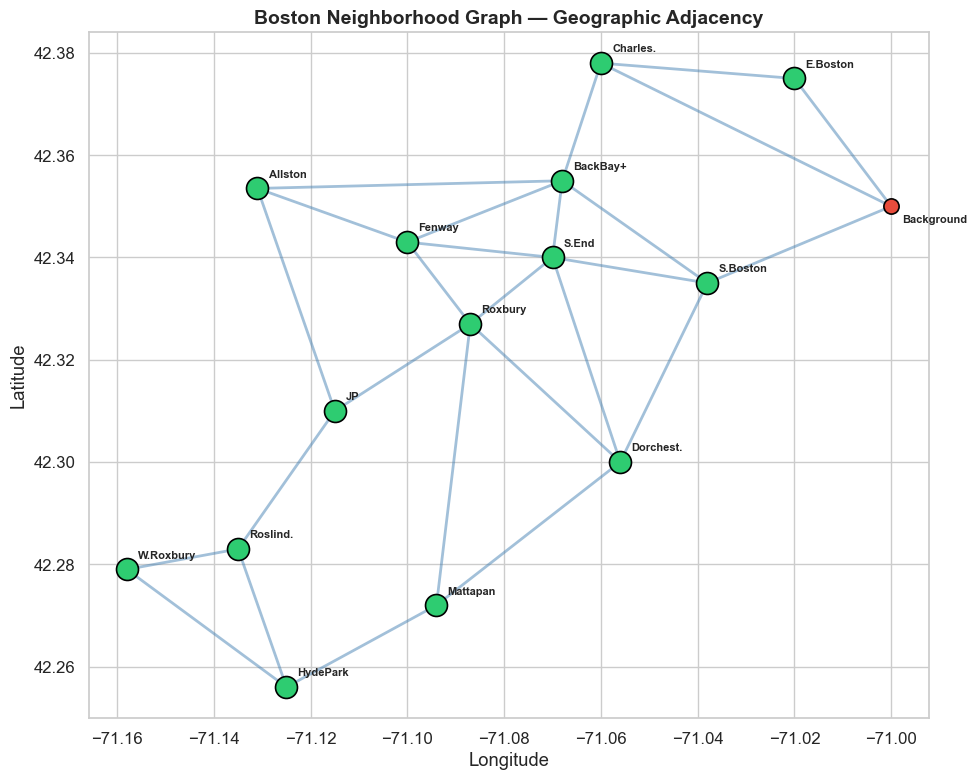

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))

# Draw edges
for i in range(N_NODES):
    for j in range(i + 1, N_NODES):
        if A[i, j] > 0:
            n1, n2 = ALL_NODES[i], ALL_NODES[j]
            x = [COORDS[n1][0], COORDS[n2][0]]
            y = [COORDS[n1][1], COORDS[n2][1]]
            ax.plot(x, y, '-', color='steelblue', alpha=0.5, linewidth=2)

# Draw nodes
for idx, n in enumerate(ALL_NODES):
    color = '#e74c3c' if n == 'Background' else '#2ecc71'
    size = 120 if n == 'Background' else 250
    ax.scatter(*COORDS[n], s=size, c=color, edgecolors='black', linewidth=1.2, zorder=5)
    offset = (8, 8) if n != 'Background' else (8, -12)
    ax.annotate(n, COORDS[n], textcoords="offset points",
                xytext=offset, fontsize=8, fontweight='bold')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Boston Neighborhood Graph — Geographic Adjacency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


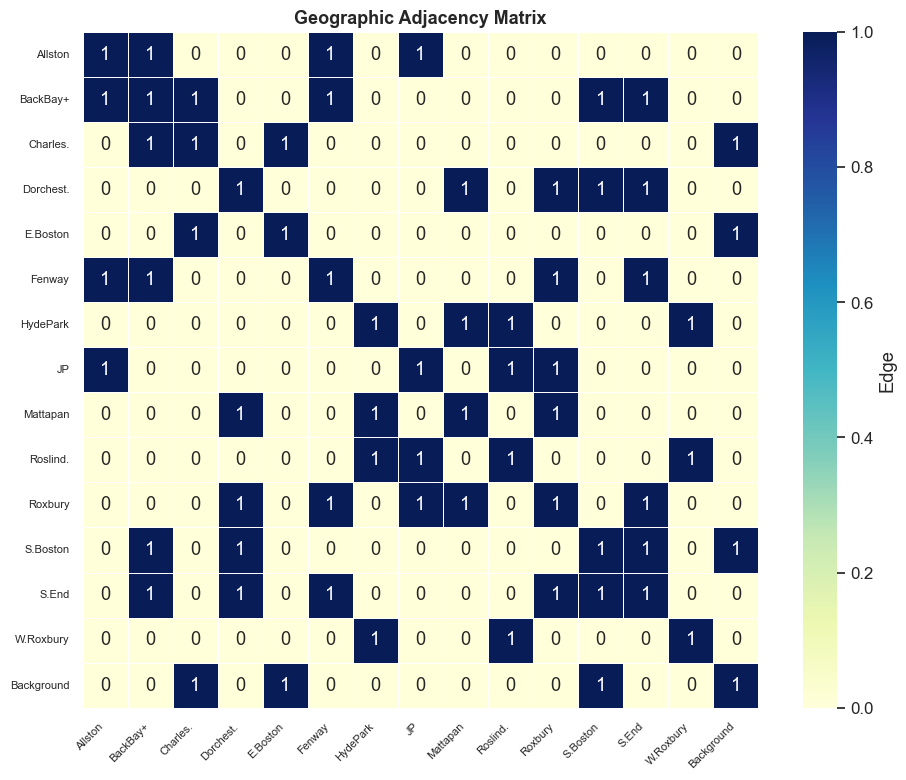

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(A, xticklabels=ALL_NODES, yticklabels=ALL_NODES,
            cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5,
            square=True, ax=ax, cbar_kws={'label': 'Edge'})
ax.set_title('Geographic Adjacency Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


## 4. Feature Assembly

We align all time series to a **common weekly index**, then build per-node feature vectors at each timestep.

**Per-node time-varying features (per lag):**
- Flu case rate (per 100k)
- Wastewater signal

**Per-node static features:**
- Population density, poverty rate, transit share, pct children, pct elderly, owner occupancy rate, no-vehicle rate, nonwhite share

**Global covariates:**
- City-wide ED ILI count
- City-wide ED ILI percentage
- Vaccination rate (season-level, forward-filled)
- City-wide monthly confirmed cases


In [13]:
# -------------------------------------------------------
# Build common weekly time index from flu_pivot
# -------------------------------------------------------
week_index = flu_pivot.index.copy()

# Align wastewater to same index (left join, forward fill gaps)
ww_aligned = ww_pivot.reindex(week_index, method='nearest', tolerance=pd.Timedelta('7D')).fillna(0)

# Align ED visits
ed_aligned = ed_merged.reindex(week_index, method='nearest', tolerance=pd.Timedelta('7D')).fillna(0)

# Align monthly demographic cases
gender_aligned = gender_monthly.reindex(week_index, method='nearest', tolerance=pd.Timedelta('7D')).fillna(0)

# Build vaccination time series (constant per season, mapped to weeks)
vacc_ts = pd.Series(0.0, index=week_index, name='vaccination_rate')
for _, vrow in vacc_df.iterrows():
    mask = (week_index >= vrow['start_date']) & (week_index <= vrow['end_date'])
    vacc_ts[mask] = vrow['vaccination_rate']
# Fill remaining with nearest non-zero
vacc_ts = vacc_ts.replace(0, np.nan).ffill().bfill().fillna(0.3)

# School calendar: approximate — in session weeks ~35-50 and 1-22 of calendar year
#school_indicator = np.array([
#    1.0 if (d.isocalendar()[1] <= 22 or d.isocalendar()[1] >= 36) else 0.0
#    for d in week_index
#])

N_WEEKS = len(week_index)
print(f"Common weekly index: {N_WEEKS} weeks")
print(f"  {week_index.min().date()} to {week_index.max().date()}")
print(f"  Flu rates shape: {flu_pivot.shape}")
print(f"  Wastewater shape: {ww_aligned.shape}")
print(f"  ED visits shape: {ed_aligned.shape}")


Common weekly index: 422 weeks
  2017-12-31 to 2026-01-25
  Flu rates shape: (422, 14)
  Wastewater shape: (422, 14)
  ED visits shape: (422, 2)


### Build PyTorch-ready tensors

In [14]:
LOOKBACK = 4   # weeks of history
HORIZON = 1    # predict 1 week ahead

# --- Normalize time-varying data ---
flu_np = flu_pivot.values.astype(np.float32)   # (T, 14)
ww_np = ww_aligned.values.astype(np.float32)   # (T, 14)

# Normalize
flu_mean, flu_std = flu_np.mean(), flu_np.std() + 1e-8
flu_norm = (flu_np - flu_mean) / flu_std

ww_mean, ww_std = ww_np.mean(), ww_np.std() + 1e-8
ww_norm = (ww_np - ww_mean) / ww_std

# ED visits normalization
ed_count_np = ed_aligned['ili_count'].values.astype(np.float32)
ed_pct_np = ed_aligned['ili_pct'].values.astype(np.float32)
ed_count_norm = (ed_count_np - ed_count_np.mean()) / (ed_count_np.std() + 1e-8)
ed_pct_norm = (ed_pct_np - ed_pct_np.mean()) / (ed_pct_np.std() + 1e-8)

# Monthly cases
monthly_cases_np = gender_aligned['monthly_cases'].values.astype(np.float32) if 'monthly_cases' in gender_aligned.columns else np.zeros(N_WEEKS, dtype=np.float32)
mc_norm = (monthly_cases_np - monthly_cases_np.mean()) / (monthly_cases_np.std() + 1e-8)

vacc_np = vacc_ts.values.astype(np.float32)

# Background node static features (neutral = 0.5)
bg_static = np.full(static_np.shape[1], 0.5, dtype=np.float32)

def build_sample(t):
    """Build one (X, global, y) sample for time t."""
    # --- Node features: [flu_lag0..lag3, ww_lag0..lag3, school, static(8)] ---
    node_feats = []
    for i in range(N_NEIGH):
        tv = []
        for lag in range(LOOKBACK):
            w = max(0, t - lag)
            tv.append(flu_norm[w, i])
            tv.append(ww_norm[w, i])
        #tv.append(school_indicator[t])
        feat = np.concatenate([tv, static_np[i]])
        node_feats.append(feat)

    # Background node
    bg_tv = np.zeros(LOOKBACK * 2, dtype=np.float32)
    #bg_tv[-1] = school_indicator[t]
    bg_feat = np.concatenate([bg_tv, bg_static])
    node_feats.append(bg_feat)

    X = np.array(node_feats, dtype=np.float32)  # (15, n_feat)

    # Global covariates
    g = np.array([
        vacc_np[t],
        ed_count_norm[t],
        ed_pct_norm[t],
        mc_norm[t],
    ], dtype=np.float32)

    # Target: next-week normalized flu rate for neighborhoods only
    y = flu_norm[min(t + HORIZON, N_WEEKS - 1), :].copy()

    return X, g, y

# Build all samples
samples = []
for t in range(LOOKBACK, N_WEEKS - HORIZON):
    X, g, y = build_sample(t)
    samples.append((X, g, y))

print(f"Total samples: {len(samples)}")
N_FEAT = samples[0][0].shape[1]
N_GLOBAL = samples[0][1].shape[0]
print(f"Node features: {N_FEAT}")
print(f"Global features: {N_GLOBAL}")


Total samples: 417
Node features: 15
Global features: 4


In [15]:
# --- Temporal train/val/test split ---
n_total = len(samples)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_samples = samples[:n_train]
val_samples = samples[n_train:n_train + n_val]
test_samples = samples[n_train + n_val:]

print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")


Train: 291 | Val: 62 | Test: 64


### Data Exploration

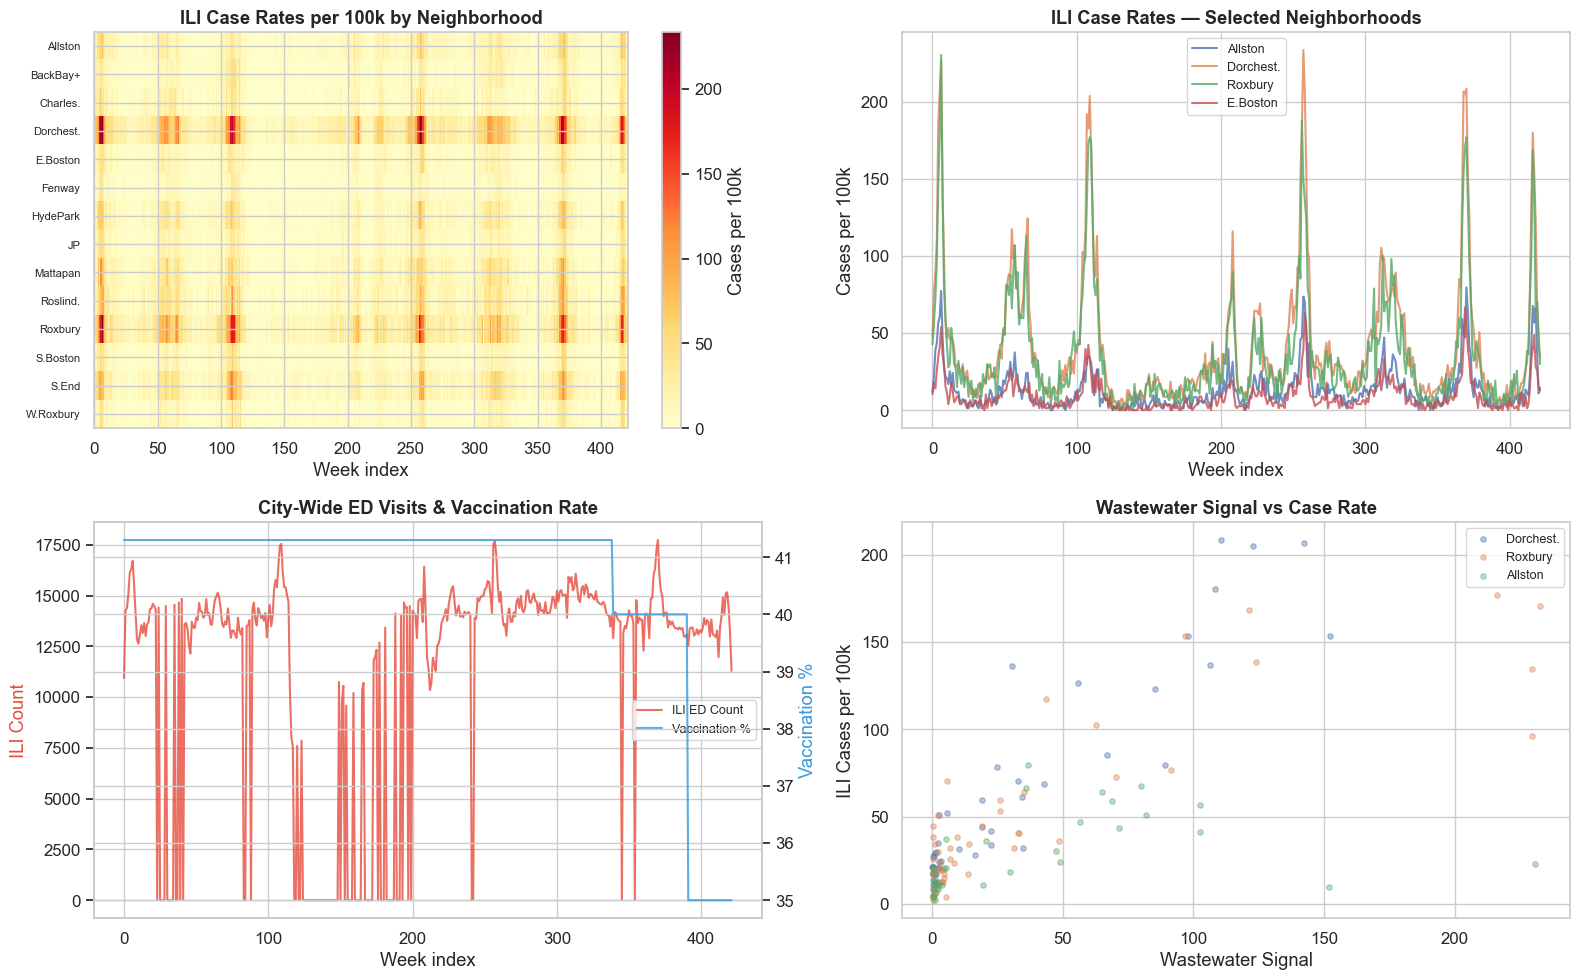

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Case rates heatmap
ax = axes[0, 0]
im = ax.imshow(flu_np.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(N_NEIGH))
ax.set_yticklabels(SHORT_NAMES, fontsize=8)
ax.set_xlabel('Week index')
ax.set_title('ILI Case Rates per 100k by Neighborhood', fontweight='bold')
plt.colorbar(im, ax=ax, label='Cases per 100k')

# (b) Selected neighborhood time series
ax = axes[0, 1]
for idx in [0, 3, 10, 4]:
    ax.plot(range(N_WEEKS), flu_np[:, idx], label=SHORT_NAMES[idx], alpha=0.8)
ax.set_xlabel('Week index')
ax.set_ylabel('Cases per 100k')
ax.set_title('ILI Case Rates — Selected Neighborhoods', fontweight='bold')
ax.legend(fontsize=9)

# (c) ED visits over time
ax = axes[1, 0]
ax.plot(range(N_WEEKS), ed_count_np, color='#e74c3c', alpha=0.8, label='ILI ED Count')
ax2 = ax.twinx()
ax2.plot(range(N_WEEKS), vacc_np * 100, color='#3498db', alpha=0.8, label='Vaccination %')
ax.set_xlabel('Week index')
ax.set_ylabel('ILI Count', color='#e74c3c')
ax2.set_ylabel('Vaccination %', color='#3498db')
ax.set_title('City-Wide ED Visits & Vaccination Rate', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# (d) Wastewater vs cases
ax = axes[1, 1]
# Only plot wastewater overlap period
for idx in [3, 10, 0]:
    mask = ww_np[:, idx] > 0
    ax.scatter(ww_np[mask, idx], flu_np[mask, idx], alpha=0.4, s=15, label=SHORT_NAMES[idx])
ax.set_xlabel('Wastewater Signal')
ax.set_ylabel('ILI Cases per 100k')
ax.set_title('Wastewater Signal vs Case Rate', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 5. GNN Model (PyTorch Geometric)

**Architecture:**
- 2× `GCNConv` layers with ReLU + dropout
- Global fusion: concatenate global covariates to every node embedding
- Output: linear head → per-node next-week flu rate prediction


In [17]:
class InfluenzaGNN(nn.Module):
    def __init__(self, n_node_feat, n_global, hidden1=64, hidden2=32, fusion_out=32, dropout=0.2):
        super().__init__()
        self.gcn1 = GCNConv(n_node_feat, hidden1)
        self.gcn2 = GCNConv(hidden1, hidden2)
        self.fusion = nn.Linear(hidden2 + n_global, fusion_out)
        self.output = nn.Linear(fusion_out, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, g_vec):
        """
        x:          (N_NODES, n_node_feat)
        edge_index: (2, E)
        g_vec:      (n_global,)
        Returns:    (N_NODES,) predicted values
        """
        # GCN layers
        h = F.relu(self.gcn1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.gcn2(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)

        # Global fusion: broadcast g_vec to all nodes
        g_expanded = g_vec.unsqueeze(0).expand(h.size(0), -1)  # (N_NODES, n_global)
        h = torch.cat([h, g_expanded], dim=1)                  # (N_NODES, hidden2+n_global)
        h = F.relu(self.fusion(h))

        # Per-node prediction
        out = self.output(h).squeeze(-1)  # (N_NODES,)
        return out


model = InfluenzaGNN(
    n_node_feat=N_FEAT,
    n_global=N_GLOBAL,
    hidden1=64,
    hidden2=32,
    fusion_out=32,
    dropout=0.2,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


InfluenzaGNN(
  (gcn1): GCNConv(15, 64)
  (gcn2): GCNConv(64, 32)
  (fusion): Linear(in_features=36, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 4,321


### Architecture Diagram

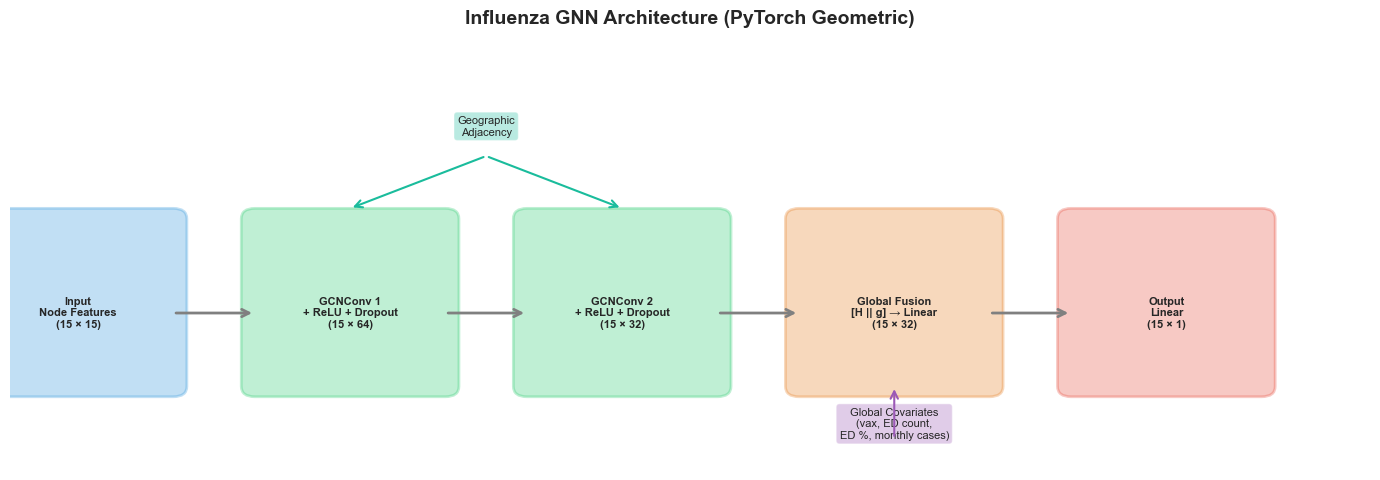

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

boxes = [
    (0.5, 1.5, f'Input\nNode Features\n(15 × {N_FEAT})', '#3498db'),
    (2.5, 1.5, 'GCNConv 1\n+ ReLU + Dropout\n(15 × 64)', '#2ecc71'),
    (4.5, 1.5, 'GCNConv 2\n+ ReLU + Dropout\n(15 × 32)', '#2ecc71'),
    (6.5, 1.5, f'Global Fusion\n[H || g] → Linear\n(15 × 32)', '#e67e22'),
    (8.5, 1.5, 'Output\nLinear\n(15 × 1)', '#e74c3c'),
]

for x, y, text, color in boxes:
    rect = mpatches.FancyBboxPatch((x - 0.7, y - 0.7), 1.4, 1.6,
                                     boxstyle="round,pad=0.1",
                                     facecolor=color, alpha=0.3, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=8, fontweight='bold')

for i in range(len(boxes) - 1):
    ax.annotate('', xy=(boxes[i + 1][0] - 0.7, boxes[i + 1][1]),
                xytext=(boxes[i][0] + 0.7, boxes[i][1]),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

ax.annotate(f'Global Covariates\n(vax, ED count,\nED %, monthly cases)',
            xy=(6.5, 0.6), fontsize=8, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='#9b59b6', alpha=0.3))
ax.annotate('', xy=(6.5, 0.8), xytext=(6.5, 0.3),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#9b59b6'))

ax.annotate('Geographic\nAdjacency',
            xy=(3.5, 3.2), fontsize=8, ha='center',
            bbox=dict(boxstyle='round', facecolor='#1abc9c', alpha=0.3))
ax.annotate('', xy=(2.5, 2.5), xytext=(3.5, 3.0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#1abc9c'))
ax.annotate('', xy=(4.5, 2.5), xytext=(3.5, 3.0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#1abc9c'))

ax.set_title('Influenza GNN Architecture (PyTorch Geometric)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 6. Training

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

edge_index_dev = edge_index.to(device)
EPOCHS = 120

train_losses = []
val_losses = []
best_val = float('inf')
best_state = None
patience_counter = 0
PATIENCE = 25

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    indices = np.random.permutation(len(train_samples))

    for idx in indices:
        X, g, y = train_samples[idx]
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        g_t = torch.tensor(g, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.float32).to(device)

        optimizer.zero_grad()
        pred = model(X_t, edge_index_dev, g_t)
        # Loss only on neighborhood nodes (not background)
        loss = criterion(pred[:N_NEIGH], y_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_samples))

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, g, y in val_samples:
            X_t = torch.tensor(X, dtype=torch.float32).to(device)
            g_t = torch.tensor(g, dtype=torch.float32).to(device)
            y_t = torch.tensor(y, dtype=torch.float32).to(device)
            pred = model(X_t, edge_index_dev, g_t)
            val_loss += criterion(pred[:N_NEIGH], y_t).item()
    val_losses.append(val_loss / len(val_samples))

    scheduler.step(val_losses[-1])

    # Early stopping
    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train MSE: {train_losses[-1]:.6f} | "
              f"Val MSE: {val_losses[-1]:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
print(f"\nBest validation MSE: {best_val:.6f}")


Epoch   1 | Train MSE: 0.495358 | Val MSE: 0.251567 | LR: 0.003000
Epoch  10 | Train MSE: 0.242685 | Val MSE: 0.147012 | LR: 0.003000
Epoch  20 | Train MSE: 0.174102 | Val MSE: 0.153120 | LR: 0.001500
Epoch  30 | Train MSE: 0.160251 | Val MSE: 0.123481 | LR: 0.001500
Epoch  40 | Train MSE: 0.167508 | Val MSE: 0.136106 | LR: 0.000750
Epoch  50 | Train MSE: 0.131955 | Val MSE: 0.123237 | LR: 0.000750
Epoch  60 | Train MSE: 0.129963 | Val MSE: 0.145745 | LR: 0.000375
Epoch  70 | Train MSE: 0.127640 | Val MSE: 0.123993 | LR: 0.000188

Early stopping at epoch 71

Best validation MSE: 0.117185


### Training & Validation Loss

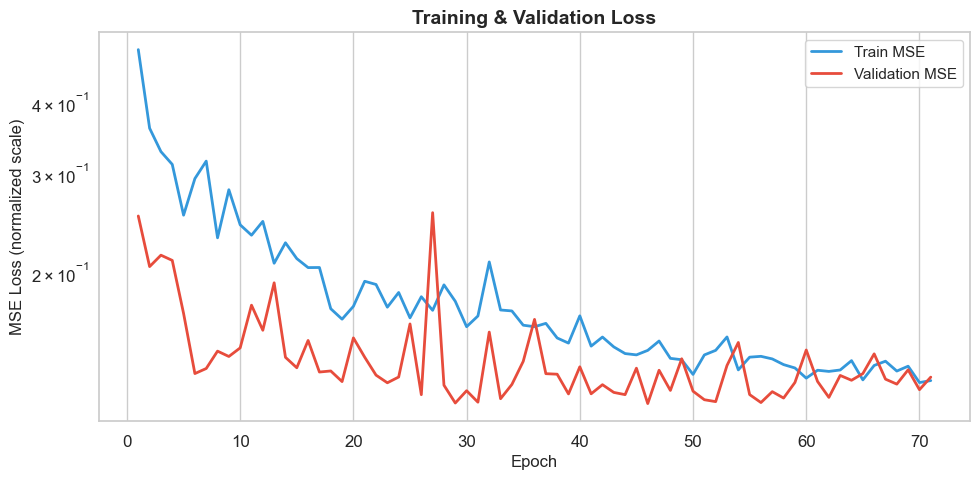

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses) + 1), train_losses, label='Train MSE', color='#3498db', linewidth=2)
ax.plot(range(1, len(val_losses) + 1), val_losses, label='Validation MSE', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss (normalized scale)', fontsize=12)
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_yscale('log')
plt.tight_layout()
plt.show()


## 7. Test Set Evaluation

In [21]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X, g, y in test_samples:
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        g_t = torch.tensor(g, dtype=torch.float32).to(device)
        pred = model(X_t, edge_index_dev, g_t)
        pred_np = pred[:N_NEIGH].cpu().numpy()
        all_preds.append(pred_np)
        all_targets.append(y)

# Denormalize back to cases per 100k
preds_arr = np.array(all_preds) * flu_std + flu_mean
targets_arr = np.array(all_targets) * flu_std + flu_mean

# Metrics
mae = np.mean(np.abs(preds_arr - targets_arr))
rmse = np.sqrt(np.mean((preds_arr - targets_arr) ** 2))
corrs = []
for i in range(N_NEIGH):
    if targets_arr[:, i].std() > 0 and preds_arr[:, i].std() > 0:
        r, _ = spearmanr(preds_arr[:, i], targets_arr[:, i])
        corrs.append(r)
    else:
        corrs.append(0.0)
mean_spearman = np.mean(corrs)

print("=" * 70)
print("TEST SET RESULTS")
print("=" * 70)
print(f"MAE:            {mae:.2f} cases per 100k")
print(f"RMSE:           {rmse:.2f} cases per 100k")
print(f"Mean Spearman ρ: {mean_spearman:.4f}")
print()
print("Per-neighborhood Spearman ρ:")
for i, n in enumerate(SHORT_NAMES):
    print(f"  {n:12s}: {corrs[i]:.4f}")


TEST SET RESULTS
MAE:            21.38 cases per 100k
RMSE:           44.42 cases per 100k
Mean Spearman ρ: 0.8589

Per-neighborhood Spearman ρ:
  Allston     : 0.9039
  BackBay+    : 0.8559
  Charles.    : 0.8095
  Dorchest.   : 0.9474
  E.Boston    : 0.8467
  Fenway      : 0.8650
  HydePark    : 0.8600
  JP          : 0.8305
  Mattapan    : 0.8660
  Roslind.    : 0.8537
  Roxbury     : 0.8932
  S.Boston    : 0.8276
  S.End       : 0.8875
  W.Roxbury   : 0.7779


### Predicted vs Actual — Time Series

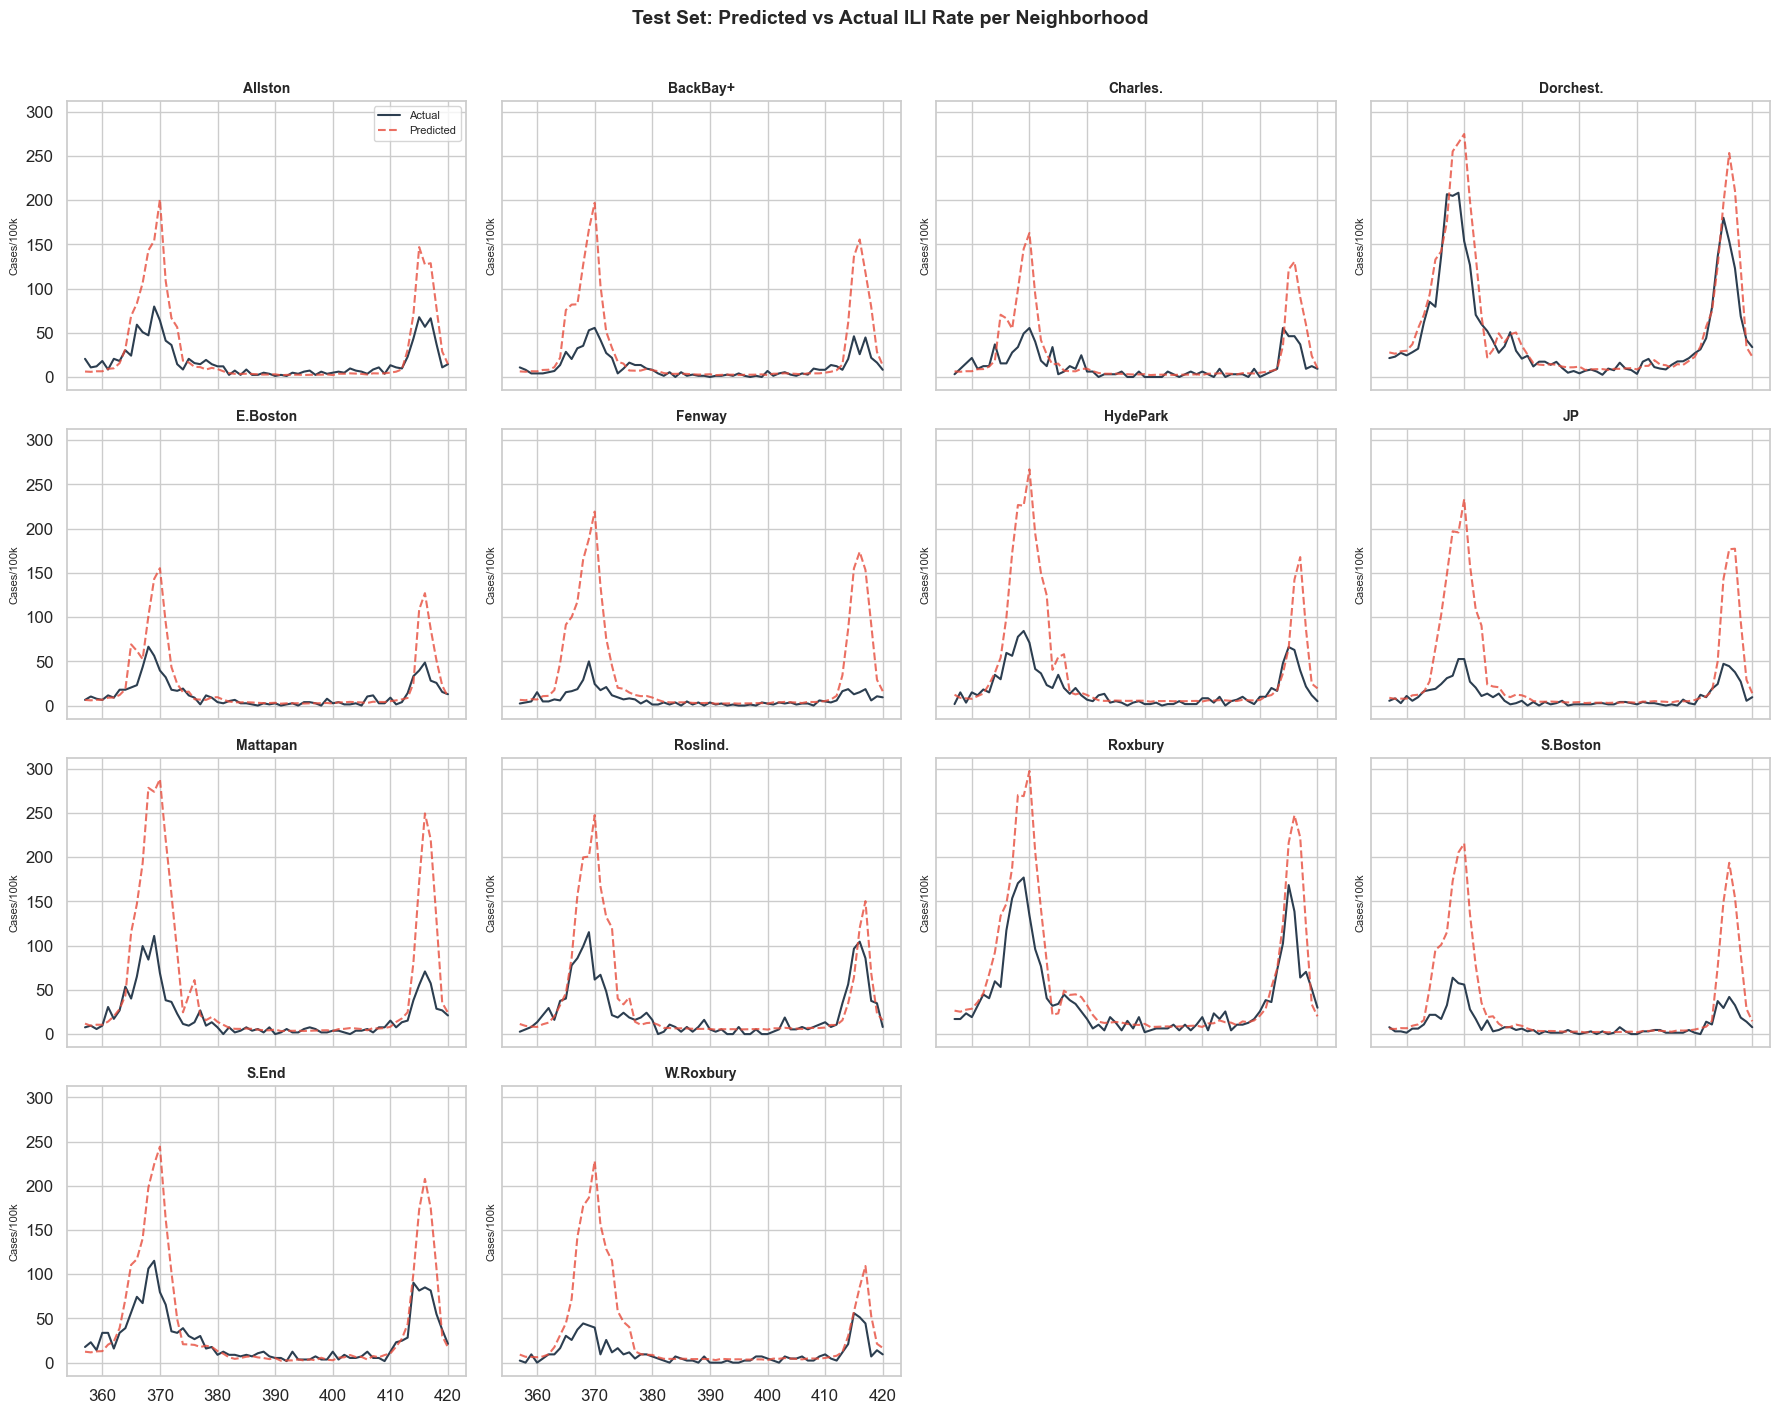

In [22]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharex=True, sharey=True)
axes_flat = axes.flatten()

test_start = n_train + n_val + LOOKBACK
test_weeks_idx = list(range(test_start, test_start + len(test_samples)))

for i in range(N_NEIGH):
    ax = axes_flat[i]
    ax.plot(test_weeks_idx, targets_arr[:, i], label='Actual', color='#2c3e50', linewidth=1.5)
    ax.plot(test_weeks_idx, preds_arr[:, i], label='Predicted', color='#e74c3c',
            linewidth=1.5, linestyle='--', alpha=0.8)
    ax.set_title(SHORT_NAMES[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Cases/100k', fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)

for i in range(N_NEIGH, len(axes_flat)):
    axes_flat[i].axis('off')

plt.suptitle('Test Set: Predicted vs Actual ILI Rate per Neighborhood',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Predicted vs Actual — Scatter

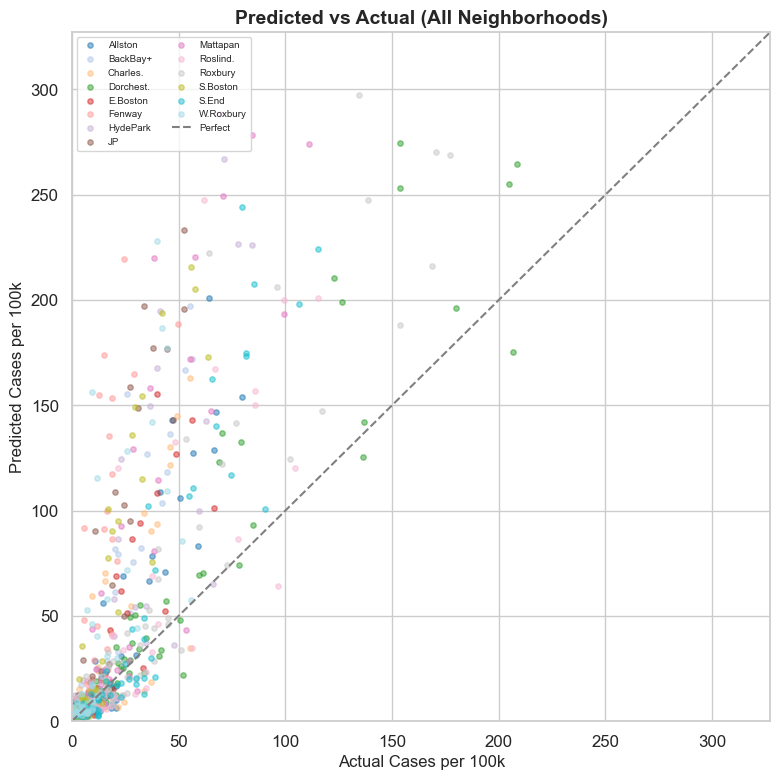

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab20(np.linspace(0, 1, N_NEIGH))

for i in range(N_NEIGH):
    ax.scatter(targets_arr[:, i], preds_arr[:, i], c=[colors[i]], s=15,
               alpha=0.5, label=SHORT_NAMES[i])

lims = [min(0, targets_arr.min(), preds_arr.min()),
        max(targets_arr.max(), preds_arr.max()) * 1.1]
ax.plot(lims, lims, '--', color='gray', linewidth=1.5, label='Perfect')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual Cases per 100k', fontsize=12)
ax.set_ylabel('Predicted Cases per 100k', fontsize=12)
ax.set_title('Predicted vs Actual (All Neighborhoods)', fontsize=14, fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()


### Spatial Prediction Heatmap (Peak Flu Week)

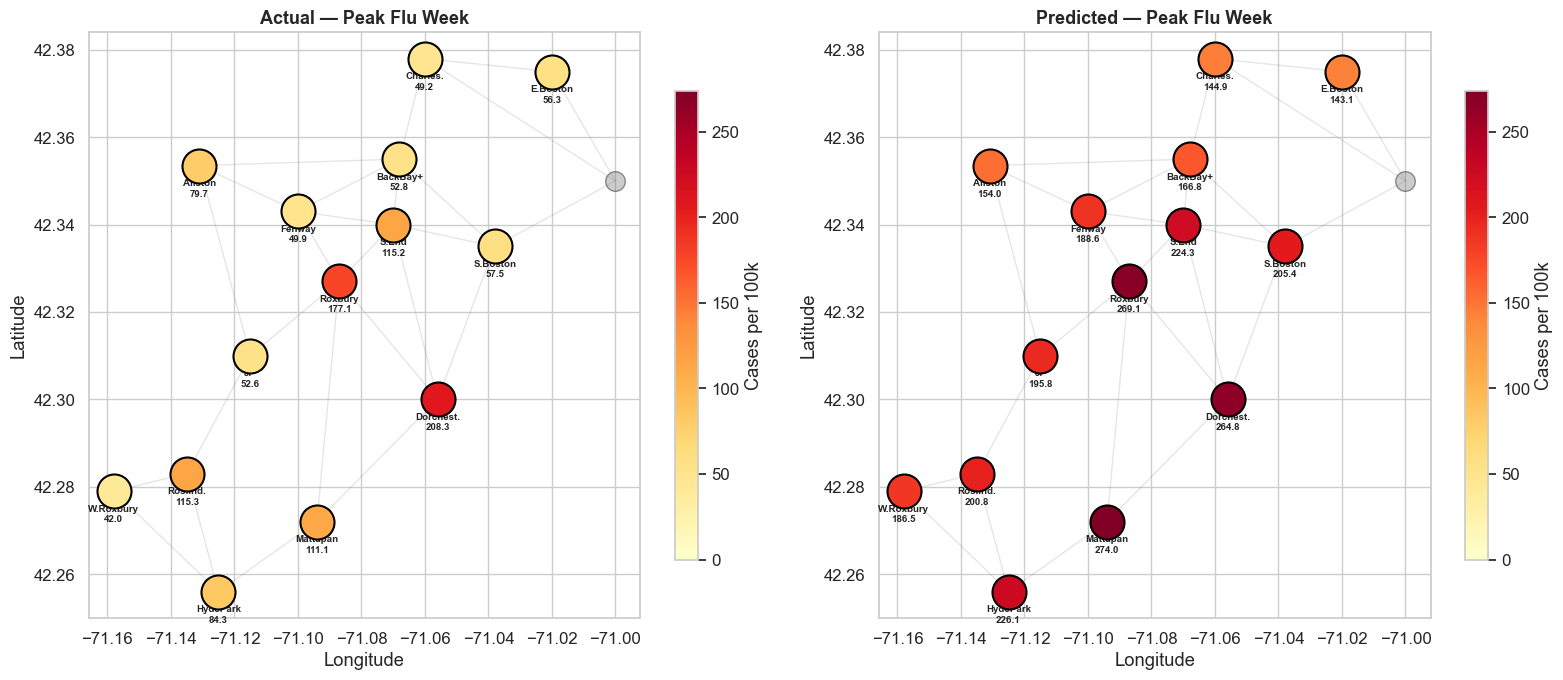

In [24]:
peak_idx = np.argmax(targets_arr.mean(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (data_slice, title) in enumerate([(targets_arr[peak_idx], 'Actual'),
                                                (preds_arr[peak_idx], 'Predicted')]):
    ax = axes[ax_idx]
    vmin = 0
    vmax = max(targets_arr[peak_idx].max(), preds_arr[peak_idx].max())
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.YlOrRd

    # Edges
    for i in range(N_NODES):
        for j in range(i + 1, N_NODES):
            if A[i, j] > 0:
                n1, n2 = ALL_NODES[i], ALL_NODES[j]
                ax.plot([COORDS[n1][0], COORDS[n2][0]],
                        [COORDS[n1][1], COORDS[n2][1]],
                        '-', color='gray', alpha=0.2, linewidth=1)

    for i, n in enumerate(SHORT_NAMES):
        color = cmap(norm(data_slice[i]))
        ax.scatter(*COORDS[n], s=600, c=[color], edgecolors='black', linewidth=1.5, zorder=5)
        ax.annotate(f"{n}\n{data_slice[i]:.1f}", COORDS[n],
                    textcoords="offset points", xytext=(0, -22),
                    fontsize=7, ha='center', fontweight='bold')

    ax.scatter(*COORDS['Background'], s=200, c='gray', edgecolors='black',
               linewidth=1, zorder=5, alpha=0.4)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, label='Cases per 100k', shrink=0.8)
    ax.set_title(f'{title} — Peak Flu Week', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()


### Per-Neighborhood Spearman Correlation

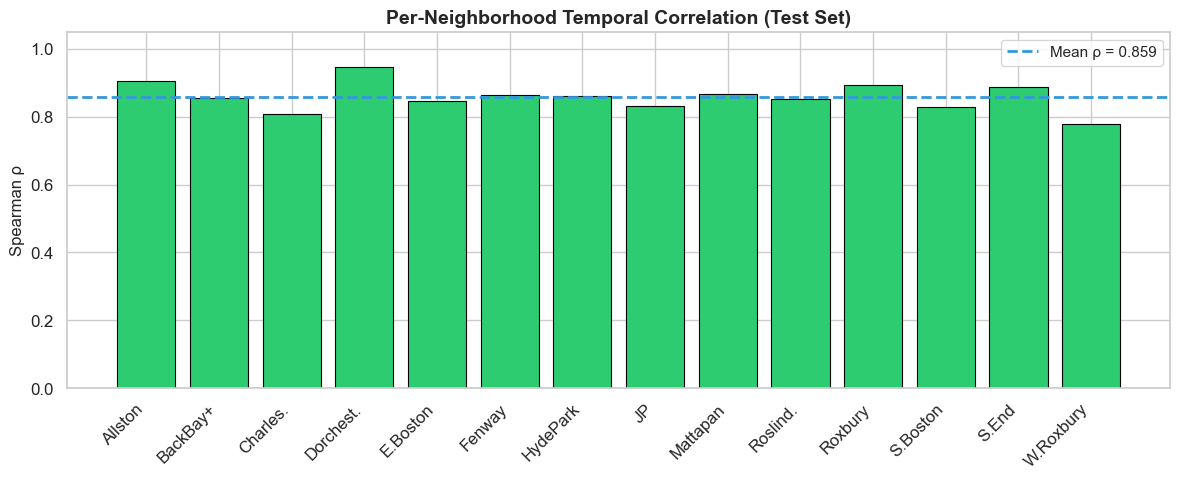

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ['#2ecc71' if c > 0.7 else '#f39c12' if c > 0.4 else '#e74c3c' for c in corrs]
ax.bar(SHORT_NAMES, corrs, color=colors_bar, edgecolor='black', linewidth=0.8)
ax.axhline(y=mean_spearman, color='#3498db', linestyle='--', linewidth=2,
           label=f'Mean ρ = {mean_spearman:.3f}')
ax.set_ylabel('Spearman ρ', fontsize=12)
ax.set_title('Per-Neighborhood Temporal Correlation (Test Set)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Spatial Spread Over Consecutive Weeks

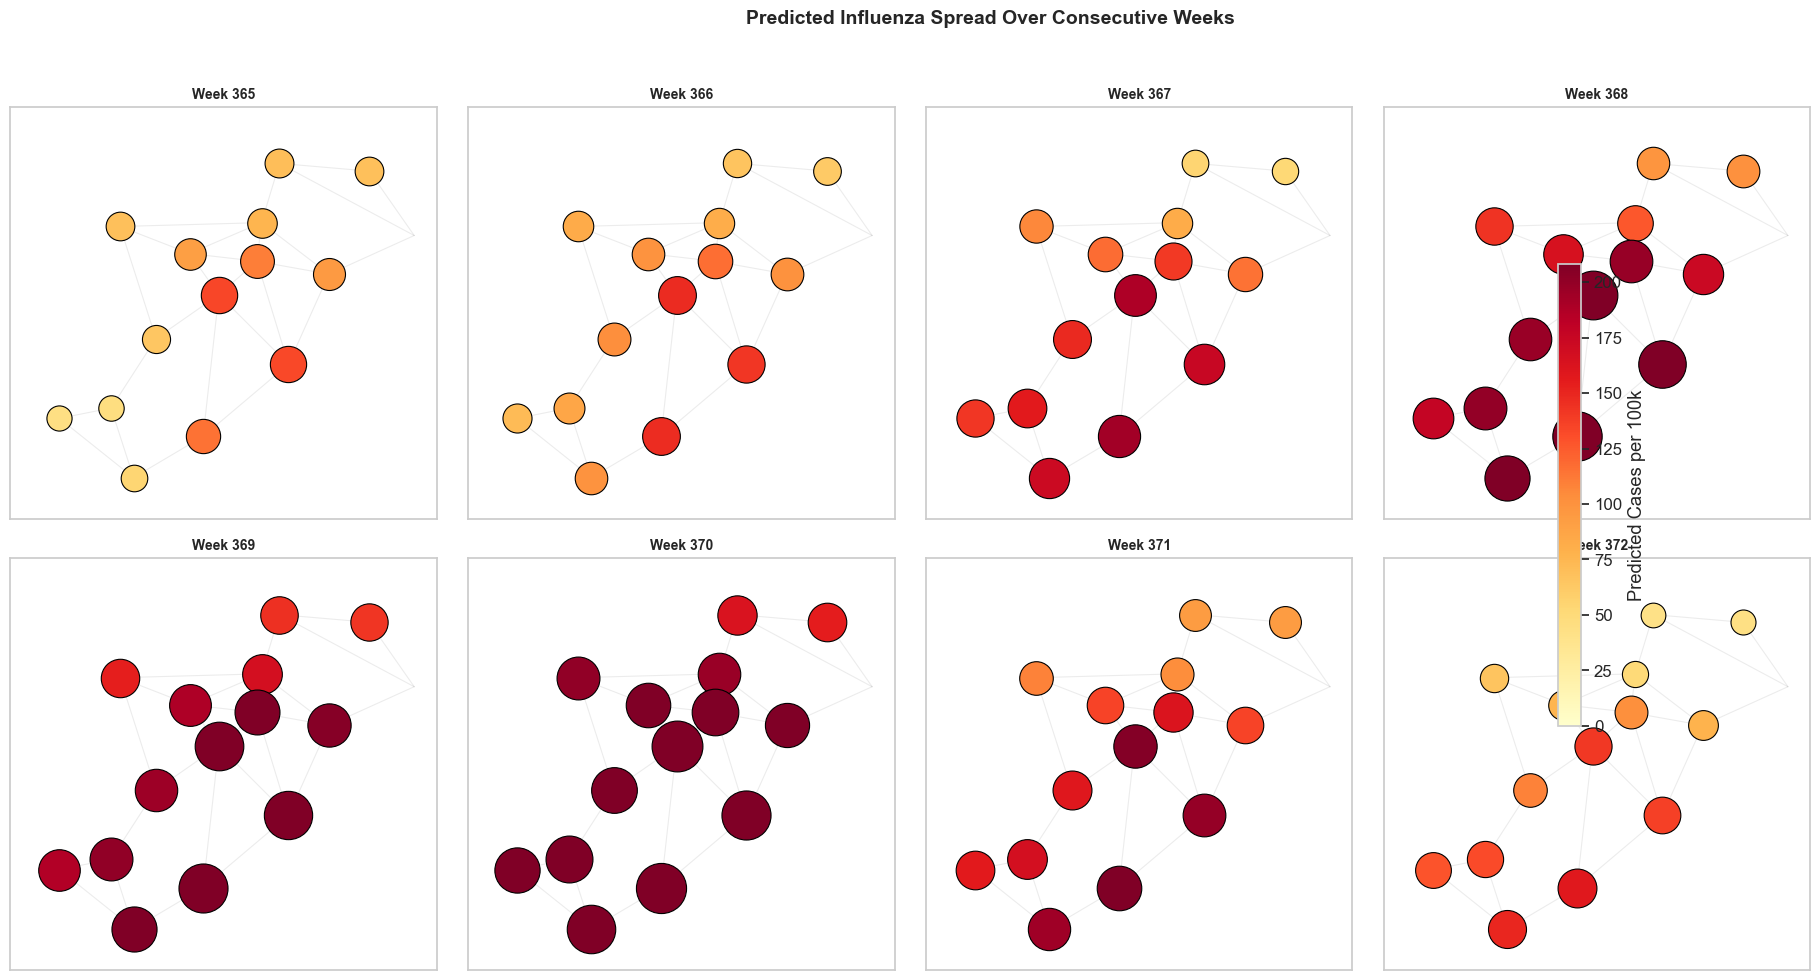

In [26]:
start = max(0, peak_idx - 4)
end = min(len(test_samples), start + 8)
selected = range(start, end)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()
vmax_global = targets_arr[start:end].max()
cmap = plt.cm.YlOrRd
norm = plt.Normalize(vmin=0, vmax=vmax_global)

for plot_idx, t_idx in enumerate(selected):
    if plot_idx >= 8:
        break
    ax = axes_flat[plot_idx]
    data_slice = preds_arr[t_idx]

    for i in range(N_NODES):
        for j in range(i + 1, N_NODES):
            if A[i, j] > 0:
                n1, n2 = ALL_NODES[i], ALL_NODES[j]
                ax.plot([COORDS[n1][0], COORDS[n2][0]],
                        [COORDS[n1][1], COORDS[n2][1]],
                        '-', color='gray', alpha=0.15, linewidth=0.8)

    for i, n in enumerate(SHORT_NAMES):
        color = cmap(norm(data_slice[i]))
        size = 150 + max(0, data_slice[i]) * 4
        ax.scatter(*COORDS[n], s=size, c=[color], edgecolors='black', linewidth=0.8, zorder=5)

    actual_week = test_weeks_idx[t_idx]
    ax.set_title(f'Week {actual_week}', fontsize=10, fontweight='bold')
    ax.set_xlim(-71.18, -70.99)
    ax.set_ylim(42.24, 42.40)
    ax.set_xticks([])
    ax.set_yticks([])

for i in range(len(selected), 8):
    axes_flat[i].axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes_flat, label='Predicted Cases per 100k', shrink=0.6, pad=0.02)
plt.suptitle('Predicted Influenza Spread Over Consecutive Weeks', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.92, 0.96])
plt.show()


## 8. Feature Importance (Gradient-Based)

We compute the mean absolute gradient of the loss w.r.t. input node features across the test set.


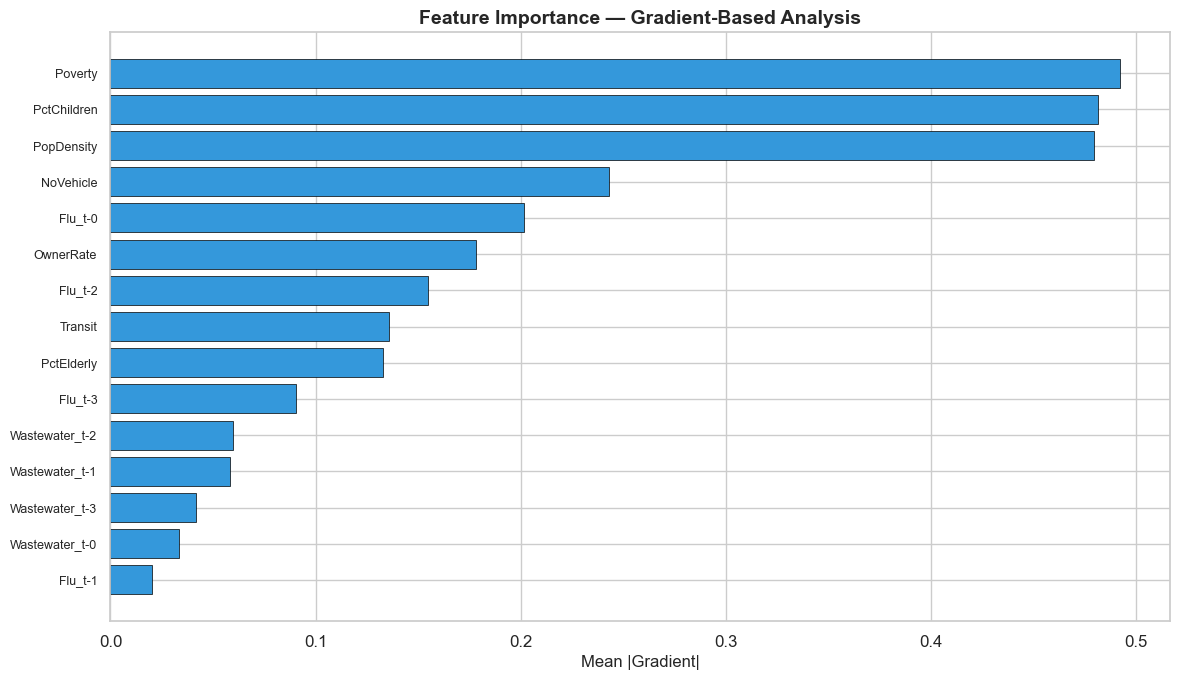

In [27]:
model.eval()
importance = torch.zeros(N_FEAT).to(device)
n_samples = 0

for X, g, y in test_samples:
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    X_t.requires_grad_(True)
    X_t.retain_grad()
    g_t = torch.tensor(g, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.float32).to(device)

    pred = model(X_t, edge_index_dev, g_t)
    loss = criterion(pred[:N_NEIGH], y_t)
    loss.backward()

    if X_t.grad is not None:
        grad = X_t.grad[:N_NEIGH].abs().mean(dim=0)
        importance += grad
        n_samples += 1

importance = (importance / max(n_samples, 1)).cpu().detach().numpy()

# Feature names
feat_names = []
for lag in range(LOOKBACK):
    feat_names.append(f'Flu_t-{lag}')
    feat_names.append(f'Wastewater_t-{lag}')
#feat_names.append('School_calendar')
# Removed nonwhiteshare
# feat_names += ['PopDensity', 'Poverty', 'Transit', 'PctChildren',
#               'PctElderly', 'OwnerRate', 'NoVehicle', 'NonwhiteShare']
    
feat_names += ['PopDensity', 'Poverty', 'Transit', 'PctChildren',
               'PctElderly', 'OwnerRate', 'NoVehicle']

sorted_idx = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(12, 7))
top_k = min(len(feat_names), 20)
ax.barh(range(top_k), importance[sorted_idx[:top_k]][::-1],
        color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_k))
ax.set_yticklabels([feat_names[i] for i in sorted_idx[:top_k]][::-1], fontsize=9)
ax.set_xlabel('Mean |Gradient|', fontsize=12)
ax.set_title('Feature Importance — Gradient-Based Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Summary

In [28]:
summary_df = pd.DataFrame({
    'Neighborhood': SHORT_NAMES,
    'Spearman_rho': [f'{c:.4f}' for c in corrs],
    'MAE': [f'{np.mean(np.abs(preds_arr[:, i] - targets_arr[:, i])):.2f}' for i in range(N_NEIGH)],
    'RMSE': [f'{np.sqrt(np.mean((preds_arr[:, i] - targets_arr[:, i])**2)):.2f}' for i in range(N_NEIGH)],
    'Mean_Actual': [f'{targets_arr[:, i].mean():.2f}' for i in range(N_NEIGH)],
    'Mean_Predicted': [f'{preds_arr[:, i].mean():.2f}' for i in range(N_NEIGH)],
})

print("=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(f"\nOverall Test MAE:       {mae:.2f} cases per 100k")
print(f"Overall Test RMSE:      {rmse:.2f} cases per 100k")
print(f"Mean Spearman ρ:        {mean_spearman:.4f}")
print(f"\nArchitecture: 2×GCNConv({N_FEAT}→64→32) + GlobalFusion(32+{N_GLOBAL}→32) + Linear(32→1)")
print(f"Graph: {N_NEIGH} neighborhoods + 1 background = {N_NODES} nodes, geographic adjacency only")
print(f"Lookback: {LOOKBACK} weeks | Horizon: {HORIZON} week")
print(f"Device: {device}")
print()
print(summary_df.to_string(index=False))


MODEL PERFORMANCE SUMMARY

Overall Test MAE:       21.38 cases per 100k
Overall Test RMSE:      44.42 cases per 100k
Mean Spearman ρ:        0.8589

Architecture: 2×GCNConv(15→64→32) + GlobalFusion(32+4→32) + Linear(32→1)
Graph: 14 neighborhoods + 1 background = 15 nodes, geographic adjacency only
Lookback: 4 weeks | Horizon: 1 week
Device: cuda

Neighborhood Spearman_rho   MAE  RMSE Mean_Actual Mean_Predicted
     Allston       0.9039 16.48 32.00       18.18          29.77
    BackBay+       0.8559 18.17 37.65       11.79          27.89
    Charles.       0.8095 15.28 29.41       12.55          23.36
   Dorchest.       0.9474 16.50 30.34       47.89          59.50
    E.Boston       0.8467 12.48 26.88       12.30          22.54
      Fenway       0.8650 27.56 55.27        7.31          34.46
    HydePark       0.8600 24.88 52.09       18.09          40.50
          JP       0.8305 26.36 53.98       10.94          36.83
    Mattapan       0.8660 32.46 65.53       20.07          50.69
 

### Save Model Checkpoint

In [29]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'edge_index': edge_index,
    'flu_mean': flu_mean,
    'flu_std': flu_std,
    'neighborhoods': NEIGHBORHOODS,
    'n_feat': N_FEAT,
    'n_global': N_GLOBAL,
}
torch.save(checkpoint, 'influenza_gnn_checkpoint.pt')
print("Model checkpoint saved to influenza_gnn_checkpoint.pt")


Model checkpoint saved to influenza_gnn_checkpoint.pt


## 10. Next Steps

**Current model uses geographic adjacency only.** Future improvements:

1. **Add MBTA mobility edges** when ridership data becomes available — weight edges by commuter flow between neighborhoods
2. **Add weather data** as a global covariate (temperature, humidity from NOAA)
3. **Experiment with architectures**: GAT (attention over neighbors), GraphSAGE, or temporal attention layers
4. **Hyperparameter search**: hidden dimensions, learning rate, lookback window, dropout rate
5. **Baseline comparisons**: ARIMA per-neighborhood, LSTM without graph, naive persistence
6. **GNNExplainer**: identify which edges and features drive each neighborhood's prediction
7. **Real-time inference**: wrap in a Flask/FastAPI endpoint for BPHC dashboard integration
